Tutorial Link: https://youtu.be/jGg_1h0qzaM?si=FzhB4BfuQrJWSAv6

In [12]:
!pip install langchain_openai
!pip install -U langchain-huggingface huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 793.2/793.2 kB 10.2 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.27.0
    Uninstalling huggingface_hub-1.27.0:
      Successfully uninstalled huggingface_hub-1.27.0


In [26]:
from typing import Union, Dict, TypedDict, Optional, Any, List
import random

from langchain_core.messages import HumanMessage, AIMessage
from langchain_openai import ChatOpenAI
from openai import OpenAI
from google.colab import userdata

from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint

from dotenv import load_dotenv # used to store API etc

from langgraph.graph import START, END
from langgraph.graph import StateGraph #framework helps to design and manage the flow of task

## Theory

### TypedDict

In [2]:
movies = {"name": "Avengers Endgame", "year": 2019}

In [3]:
class Movie(TypedDict):
  name : str
  year : int

movie = Movie(name = "Avengers Endgame", year = 2019)

movie

{'name': 'Avengers Endgame', 'year': 2019}

### Union

In [4]:
def square(x : Union[int, float]) -> float:
  return x*x

In [5]:
square(2)

4

### Optional

In [6]:
def nice_message(name: Optional[str]) -> None:
  if name is None:
    print("Hey random person!")
  else:
    print(f"Hi there {name}!")

In [7]:
nice_message(None)

Hey random person!


### Any

In [8]:
def print_value(x : Any):
  print(x)

print_value("abc")

abc


### Lambda Function

In [9]:
square = lambda x: x*x
square(10)

100

In [10]:
nums = [1,2,3,4]
squares = list(map(lambda x:x*x, nums))
squares

[1, 4, 9, 16]

## First Graph

In [11]:
# creating States

class AgentState(TypedDict): # our state schema
  message: str

# Node
def greeting_node(state: AgentState) -> AgentState:
  """
  simple node that adds a greeting node to the state
  """
  state["message"] = "Hey " + state["message"] + ", how is your day going?"
  return state

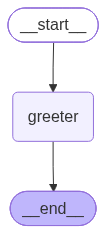

In [12]:
graph = StateGraph(AgentState)

graph.add_node("greeter", greeting_node)
graph.set_entry_point("greeter") # setting connection between start and none
graph.set_finish_point("greeter")
app = graph.compile()

app

In [13]:
result = app.invoke({"message":"Bob"})

In [14]:
result["message"]

'Hey Bob, how is your day going?'

## Exercise 1:

In [15]:
# creating States
class AgentState(TypedDict): # our state schema
  compliment: str

# Node
def complimenting_node(state: AgentState) -> AgentState:
  """
  simple node that adds a compliment node to the state
  """
  state["compliment"] = state["compliment"] + ", you're doing an amazing job learning LangGraph!"

  return state

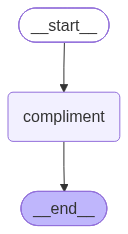

In [16]:
graph = StateGraph(AgentState)

graph.add_node("compliment", complimenting_node)
graph.set_entry_point("compliment") # setting connection between start and node
graph.set_finish_point("compliment")
app = graph.compile()

app

In [17]:
result = app.invoke({"compliment":"Bob"})
result["compliment"]

"Bob, you're doing an amazing job learning LangGraph!"

## Second Graph

In [18]:
class AgentState(TypedDict):
  values: List[int]
  name: str
  result: str

#building Node:
def process_values(state: AgentState) -> AgentState:
  """
  handling multiple inputs
  """
  print(state)

  state['result'] = "Hi there! " + state['name'] + f" Your sum is {sum(state['values'])}"

  print(state)
  return state



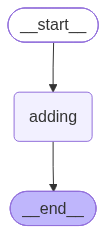

In [19]:
#creating graph
graph = StateGraph(AgentState)
graph.add_node("adding",process_values)
graph.set_entry_point("adding")
graph.set_finish_point("adding")

visual = graph.compile()
visual

In [20]:
answers = visual.invoke({"values":[1,2,3,4], "name":"Steve"})
# answers

{'values': [1, 2, 3, 4], 'name': 'Steve'}
{'values': [1, 2, 3, 4], 'name': 'Steve', 'result': 'Hi there! Steve Your sum is 10'}


In [21]:
answers["result"]

'Hi there! Steve Your sum is 10'

## Exercise 2:

In [22]:
class State(TypedDict):
  values: List[int]
  name: str
  operation: str
  result: str

#building Node:
def process_values(state: State) -> State:
  """
  handling multiple inputs
  """
  summed = sum(state['values'])
  product = 1
  for i in range(len(state["values"])):
    product *= state["values"][i]

  if state['operation'] == "+":
    state['result'] = "Hi there! " + state['name'] + f" Your answer is " + str(summed)
  else:
    state['result'] = "Hi there! " + state['name'] + f" Your answer is " + str(product)

  return state



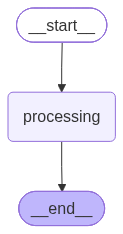

In [23]:
#creating graph
graph = StateGraph(State)
graph.add_node("processing", process_values)
graph.set_entry_point("processing")
graph.set_finish_point("processing")

visual = graph.compile()
visual

In [24]:
answers = visual.invoke({"values":[1,2,3,4], "name":"Steve", "operation":"+"})
answers['result']

'Hi there! Steve Your answer is 10'

## Third Graph: Multiple Nodes

In [25]:
class AgentState(TypedDict):
  name: str
  age: int
  final: str

# nodes:
def first_node(state: AgentState) -> AgentState:
  """first node"""
  state['final'] = f"Hi {state['name']}!"
  return state

def second_node(state: AgentState) -> AgentState:
  """second node"""
  state['final'] = state['final'] + f" You are {state['age']} years old!"
  return state


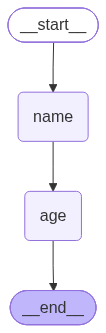

In [26]:
#creating graph
graph = StateGraph(AgentState)
graph.add_node("name", first_node)
graph.add_node("age", second_node)
graph.set_entry_point("name")
graph.add_edge("name","age")
graph.set_finish_point("age")

visual = graph.compile()
visual

In [27]:
answers = visual.invoke({"name":"Charlie", "age":30})
answers['final']

'Hi Charlie! You are 30 years old!'

## Exercise 3:

In [28]:
class AgentState(TypedDict):
  name: str
  age: int
  skills: List[str]
  final: str

# nodes:
def first_node(state: AgentState) -> AgentState:
  """first node"""
  state['final'] = f"{state['name']}, welcome to the system!"
  return state

def second_node(state: AgentState) -> AgentState:
  """second node"""
  state['final'] = state['final'] + f" You are {state['age']} years old!"
  return state

def third_node(state: AgentState) -> AgentState:
  """third node"""
  state['final'] = state['final'] + f" You have skills in: {state['skills']}."
  return state


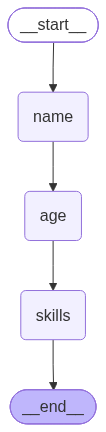

In [29]:
#creating graph
graph = StateGraph(AgentState)
graph.add_node("name", first_node)
graph.add_node("age", second_node)
graph.add_node("skills", third_node)
graph.set_entry_point("name")
graph.add_edge("name","age")
graph.add_edge("age","skills")
graph.set_finish_point("skills")

visual = graph.compile()
visual

In [30]:
answers = visual.invoke({"name":"Lisa", "age":30, "skills": ["Python", "ML", "LangGraph"]})
answers['final']

"Lisa, welcome to the system! You are 30 years old! You have skills in: ['Python', 'ML', 'LangGraph']."

## Fourth Graph: Conditional Graph

In [31]:
class AgentState(TypedDict):
  number1: int
  operation: str
  number2: int
  final: int

# nodes:
def adder(state: AgentState) -> AgentState:
  """adds"""
  state['final'] = state['number1'] + state['number2']
  return state

def subtractor(state: AgentState) -> AgentState:
  """minus"""
  state['final'] = state['number1'] - state['number2']
  return state

def decide_next_node(state: AgentState) -> AgentState:
  """decides next node"""
  if state['operation'] == "+":
    return "adding"
  elif state['operation'] == "-":
    return "subtracting"

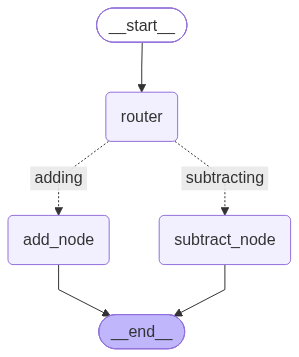

In [32]:
#creating graph
graph = StateGraph(AgentState)
graph.add_node("router", lambda state: state) #input and output is the same state!
graph.add_node("add_node", adder)
graph.add_node("subtract_node", subtractor)

graph.add_edge(START, "router")

graph.add_conditional_edges(
    "router",
    decide_next_node,
    {
        "adding": "add_node",
        "subtracting": "subtract_node"
    }
)

graph.add_edge("add_node", END)
graph.add_edge("subtract_node", END)

visual = graph.compile()
visual

In [33]:
initial_state_1 = AgentState(number1 = 10, operation = "-", number2 = 5)
visual.invoke(initial_state_1)

{'number1': 10, 'operation': '-', 'number2': 5, 'final': 5}

## Exercise 4:

In [34]:
class AgentState(TypedDict):
  number1: int
  operation: str
  number2: int
  number3: int
  operation2: str
  number4: int
  final: int
  final2: int

# nodes:
def adder(state: AgentState) -> AgentState:
  """adds"""
  state['final'] = state['number1'] + state['number2']
  return state

def subtractor(state: AgentState) -> AgentState:
  """minus"""
  state['final'] = state['number1'] - state['number2']
  return state

def decide_next_node(state: AgentState) -> AgentState:
  """decides next node"""
  if state['operation'] == "+":
    return "adding"
  elif state['operation'] == "-":
    return "subtracting"

def adder2(state: AgentState) -> AgentState:
  """adds"""
  state['final2'] = state['number3'] + state['number4']
  return state

def subtractor2(state: AgentState) -> AgentState:
  """minus"""
  state['final2'] = state['number3'] - state['number4']
  return state

def decide_next_node2(state: AgentState) -> AgentState:
  """decides next node"""
  if state['operation2'] == "+":
    return "adding2"
  elif state['operation2'] == "-":
    return "subtracting2"

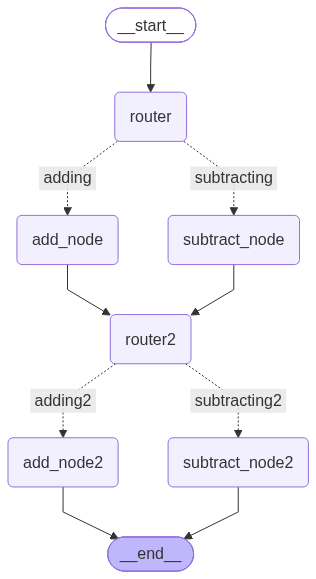

In [35]:
#creating graph
graph = StateGraph(AgentState)
graph.add_node("router", lambda state: state) #input and output is the same state!
graph.add_node("add_node", adder)
graph.add_node("subtract_node", subtractor)

graph.add_node("router2", lambda state: state) #input and output is the same state!
graph.add_node("add_node2", adder2)
graph.add_node("subtract_node2", subtractor2)


graph.add_edge(START, "router")

graph.add_conditional_edges(
    "router",
    decide_next_node,
    {
        "adding": "add_node",
        "subtracting": "subtract_node"
    }
)


graph.add_edge("add_node", "router2")
graph.add_edge("subtract_node", "router2")

graph.add_conditional_edges(
    "router2",
    decide_next_node2,
    {
        "adding2": "add_node2",
        "subtracting2": "subtract_node2"
    }
)

graph.add_edge("add_node2", END)
graph.add_edge("subtract_node2", END)

visual = graph.compile()
visual

In [36]:
initial_state = AgentState(number1 = 10, operation = "-", number2 = 5,
                           number3 = 7, operation2 = "+", number4 = 2
                           )
visual.invoke(initial_state)

{'number1': 10,
 'operation': '-',
 'number2': 5,
 'number3': 7,
 'operation2': '+',
 'number4': 2,
 'final': 5,
 'final2': 9}

## Fifth Graph: Looping Graph

In [37]:
# creating States
class AgentState(TypedDict): # our state schema
  name: str
  number: List[int]
  counter: int

# Node
def greeting_node(state: AgentState) -> AgentState:
  """
  simple node that adds a greeting node to the state
  """
  state["name"] = "Hi there " + state["name"]
  state["counter"] = 0
  return state

def random_node(state: AgentState) -> AgentState:
  """
  generate a random number from 0 to 10
  """
  state['number'].append(random.randint(0,10))
  state['counter'] += 1
  return state
  pass


def should_continue(state: AgentState) -> AgentState:
  """
  loop
  """
  if state['counter'] < 5:
    print("entering loop", state['counter'])
    return "loop"
  else:
    return "exit"

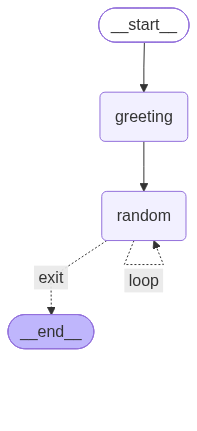

In [38]:
#creating graph
graph = StateGraph(AgentState)
graph.add_node("greeting", greeting_node)
graph.add_node("random", random_node)

graph.add_edge(START, "greeting")
graph.add_edge("greeting", "random")

graph.add_conditional_edges(
    "random",
    should_continue,
    {
        "loop": "random", # back to same node!
        "exit": END
    }
)


visual = graph.compile()
visual

In [39]:
initial_state = AgentState(name = "Nik", number = [], counter = -2)
visual.invoke(initial_state)

entering loop 1
entering loop 2
entering loop 3
entering loop 4


{'name': 'Hi there Nik', 'number': [10, 5, 9, 7, 1], 'counter': 5}

## Exercise 5:

In [43]:
# creating States
class AgentState(TypedDict): # our state schema
  player_name: str
  guesses: List[int]
  attempts: int
  lower_bound: int
  upper_bound: int

number = 5
# Node
def setup_node(state: AgentState) -> AgentState:
  """
  This node has the number to be guessed
  """
  number = number
  return state
  pass

def guess_node(state: AgentState) -> AgentState:
  """
  This node explains the rules of the game and asks the player to guess the number
  """
  state['player_name'] = f"""Hi {state['player_name']}!
  Welcome to the game! You have to guess a number between 2 bounds.
  And I will hint you lower or upper.
  You 7 attempts to correctly guess.
  Now, guess a number between {state['lower_bound']} and {state['upper_bound']}..."""

  state['guesses']

  pass


def hint_node(state: AgentState) -> AgentState:
  """
  This nodes provides the hint based on previous answer
  """
  if state['guesses'][-1] > number:
    return "Lower"
  elif state['guesses'][-1] < number:
    return "Higher"
  else:
    return "exist"

    pass

## Agent 1

In [19]:
# creating States

class AgentState(TypedDict): # our state schema
  message: List[HumanMessage]

HF_TOKEN = userdata.get("HF_TOKEN")

llm_endpoint = HuggingFaceEndpoint(
    repo_id="openai/gpt-oss-120b",
    huggingfacehub_api_token=HF_TOKEN,
)

llm = ChatHuggingFace(llm=llm_endpoint)

# Node
def process(state: AgentState) -> AgentState:
  """
  simple node that adds a greeting node to the state
  """
  response = llm.invoke(state['message'])
  print(f"\nAI: {response.content}")
  return state

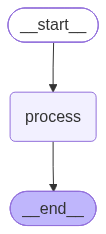

In [18]:
graph = StateGraph(AgentState)
graph.add_node("process", process)
graph.add_edge(START, "process") # setting connection between start and none
graph.add_edge("process", END)
app = graph.compile()

app

In [25]:
user_input = input("Enter: ")
while user_input != "exit":
  app.invoke({"message": [HumanMessage(content = user_input)]})
  user_input = input("Enter: ")

Enter: Hi there

AI: Hello! 👋 How can I assist you today?
Enter: I don't know

AI: I’m happy to help—what’s on your mind?  

If you’re feeling stuck or unsure about something (a decision, a topic you’re learning, a problem you’re working on, etc.), just let me know a bit more about the situation, and I’ll do my best to give you the information, guidance, or a fresh perspective you need. 🌟
Enter: is my data safe, or are you sending it?

AI: **Your privacy matters, and here’s how the data you share with me is handled**

| What you type | What happens to it? | Who can see it? |
|---------------|--------------------|-----------------|
| **During the conversation** | The text is transmitted over an encrypted (HTTPS) connection to the servers that run the model. | Only the servers that host the model receive it. No third‑party services are involved. |
| **After the response is generated** | The content is used for a short period to generate the reply and then discarded from the active sessio

## Agent 2: Memory Chatbot

In [52]:
# creating States
class AgentState(TypedDict): # our state schema
  messages: List[Union[HumanMessage, AIMessage]]


HF_TOKEN = userdata.get("HF_TOKEN")
repo_id="meta-llama/Llama-3.1-8B-Instruct:novita"

llm_endpoint = HuggingFaceEndpoint(
    repo_id=repo_id,
    huggingfacehub_api_token=HF_TOKEN,
)

llm = ChatHuggingFace(llm=llm_endpoint)

# Node
def process(state: AgentState) -> AgentState:
  """
  A node solves the request your input
  """
  response = llm.invoke(state['messages'])
  state['messages'].append(AIMessage(content = response.content))

  print(f"\nAI: {response.content}")

  return state

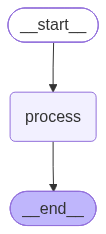

In [53]:
graph = StateGraph(AgentState)
graph.add_node("process", process)
graph.add_edge(START, "process") # setting connection between start and none
graph.add_edge("process", END)
app = graph.compile()

app

In [58]:
conversation_history = []
user_input = input("Enter: ")
while user_input != "exit":
  conversation_history.append(HumanMessage(content =  user_input))
  result = app.invoke({"messages": conversation_history}) # entire conversation history is sent
  conversation_history = result['messages']
  user_input = input("Enter: ")

Enter: hi

AI: How can I assist you today?
Enter: idk

AI: Sometimes it's hard to know where to start. If you're feeling stuck, we could play a game, chat about a topic that interests you, or I could suggest some conversation starters.

Would you like to:

1. Play a game (e.g., 20 Questions, Would You Rather)?
2. Discuss a topic (e.g., hobbies, movies, books)?
3. Generate a random conversation starter?

Let me know, and I'll do my best to help!
Enter: exist

AI: Existence is a complex and abstract concept that has been debated by philosophers, scientists, and thinkers for centuries.

From a philosophical perspective, the question of existence can be broken down into several sub-questions:

1. What is the nature of existence?
2. Does existence depend on perception or reality?
3. Is existence a fundamental aspect of the universe or a product of human consciousness?

Some philosophical theories that attempt to answer these questions include:

1. Existentialism: This philosophy posits that

## Storing in a Text File

In [56]:
conversation_history = []
user_input = input("Enter: ")
while user_input != "exit":
  conversation_history.append(HumanMessage(content =  user_input))
  result = app.invoke({"messages": conversation_history}) # entire conversation history is sent
  conversation_history = result['messages']
  user_input = input("Enter: ")

Enter: hi

AI: It's nice to meet you. Is there something I can help you with or would you like to chat?
Enter: good morning

AI: Good morning. How's your day starting out?
Enter: tell me a joke

AI: A man walked into a library and asked the librarian, "Do you have any books on Pavlov's dogs and Schrödinger's cat?" The librarian replied, "It rings a bell, but I'm not sure if it's here or not."
Enter: exit


In [57]:
with open("logging.txt","w") as file:
  file.write("your conversation log:\n")

  for message in conversation_history:
    if isinstance(message, HumanMessage):
      file.write(f"You: {message.content}\n")
    elif isinstance(message, AIMessage):
      file.write(f"AI: {message.content}\n\n")
  file.write("End of Conversation")

  print("Conversation saved to logging.txt")

Conversation saved to logging.txt
